In [2]:
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Dataset

In [3]:
class KeypointDataset(Dataset):
    def __init__(self, csv_path):
        self.samples = []
        with open(csv_path, "r") as f:
            reader = csv.reader(f)
            for row in reader:
                label = int(row[0])
                points = list(map(float, row[1:]))
                self.samples.append((points, label))

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        points, label = self.samples[idx]
        points = torch.tensor(points, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)
        return points, label


# Model

In [4]:
# Initialize the model
from keypoint_classifier import KeyPointModel

# Train

In [10]:
loss_history = []
acc_history = []

# Paths
dataset_path = "dataset/keypoint.csv"
dataset = KeypointDataset(dataset_path)
NUM_CLASSES = len(set([label for _, label in dataset.samples]))

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = KeyPointModel(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 100

for epoch in range(EPOCHS):
	total_loss = 0
	total_correct = 0
	total_samples = 0
	
	for points, labels in train_loader:
		points, labels = points.to(device), labels.to(device)
		
		optimizer.zero_grad()
		
		logits = model(points)
		loss = nn.functional.cross_entropy(logits, labels)
		
		loss.backward()
		optimizer.step()

		preds = torch.argmax(logits, dim=1)
		total_correct += (preds == labels).sum().item()
		total_samples += labels.size(0)
		
		total_loss += loss.item()
	
	epoch_loss = total_loss / len(train_loader)
	epoch_acc = total_correct / total_samples

	loss_history.append(epoch_loss)
	acc_history.append(epoch_acc)

	print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

model_save_path = "keypoint_model.pth"
torch.save(model.state_dict(), model_save_path)

Epoch 1/100  Loss: 1.6167  Acc: 0.1867
Epoch 2/100  Loss: 1.6151  Acc: 0.1933
Epoch 3/100  Loss: 1.5993  Acc: 0.2467
Epoch 4/100  Loss: 1.5915  Acc: 0.2400
Epoch 5/100  Loss: 1.5838  Acc: 0.2800
Epoch 6/100  Loss: 1.5747  Acc: 0.3133
Epoch 7/100  Loss: 1.5665  Acc: 0.3467
Epoch 8/100  Loss: 1.5416  Acc: 0.3533
Epoch 9/100  Loss: 1.5277  Acc: 0.3800
Epoch 10/100  Loss: 1.5013  Acc: 0.4133
Epoch 11/100  Loss: 1.5005  Acc: 0.4533
Epoch 12/100  Loss: 1.4695  Acc: 0.5133
Epoch 13/100  Loss: 1.4424  Acc: 0.5667
Epoch 14/100  Loss: 1.4257  Acc: 0.5267
Epoch 15/100  Loss: 1.4046  Acc: 0.6400
Epoch 16/100  Loss: 1.3616  Acc: 0.6533
Epoch 17/100  Loss: 1.3487  Acc: 0.6267
Epoch 18/100  Loss: 1.3106  Acc: 0.6333
Epoch 19/100  Loss: 1.3097  Acc: 0.5667
Epoch 20/100  Loss: 1.2281  Acc: 0.6333
Epoch 21/100  Loss: 1.2371  Acc: 0.5800
Epoch 22/100  Loss: 1.1762  Acc: 0.6733
Epoch 23/100  Loss: 1.1619  Acc: 0.6133
Epoch 24/100  Loss: 1.1156  Acc: 0.6467
Epoch 25/100  Loss: 1.0923  Acc: 0.6333
Epoch 26/

# Loss Curve and Accuracy Curve

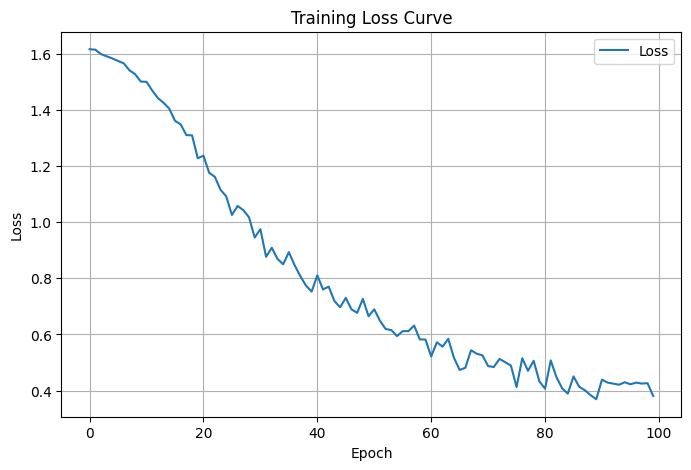

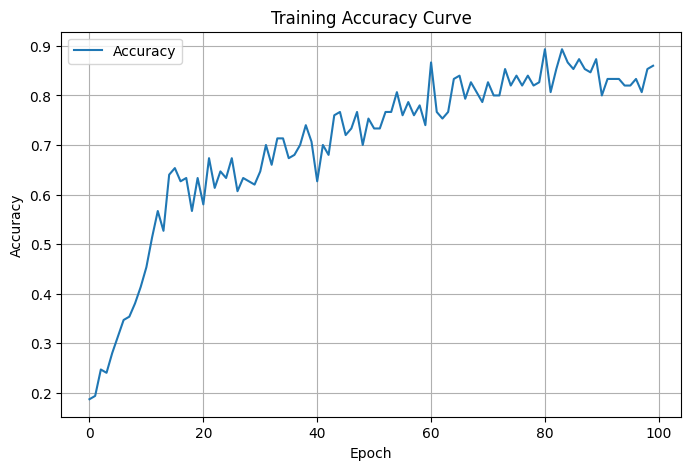

In [11]:
import matplotlib.pyplot as plt

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(loss_history, label="Loss")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(acc_history, label="Accuracy")
plt.title("Training Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# Per-class Accuracy Bar Chart